## 1. Entorno y configuración

`config/labels.yaml` contiene los umbrales y las fuentes opcionales. Con `phase_a_run: null`
se selecciona la última fase A satisfactoria con hashes. Puedes fijar una ruta relativa
como `reports/fase_a/20260906T142956_752136Z` para reproducir una ejecución concreta.
Si los datos han cambiado desde ese manifiesto, la carga se detiene: ejecuta de nuevo 00.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import geopandas as gpd
import yaml
from IPython.display import display

PROJECT_ROOT_OVERRIDE = None
start = Path(PROJECT_ROOT_OVERRIDE or Path.cwd()).resolve()
candidates = [p for parent in (start, *start.parents) for p in (parent, parent / "Proyecto Con Luis")]
ROOT = next((p for p in candidates if (p / "config/labels.yaml").is_file()
             and (p / "src/geoau/labels.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Indica PROJECT_ROOT_OVERRIDE o abre el notebook dentro del proyecto.")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from geoau.local_sources import local_path, read_table, read_vector, sha256_file, verify_unchanged, write_json
from geoau.labels import (load_phase_a, reconcile, normalize_indicios, apply_reviews, geometry_qc,
                         group_candidates, define_labels, coverage_at_points, export_phase_b)
CONFIG = yaml.safe_load((ROOT / "config/labels.yaml").read_text(encoding="utf-8"))
assert CONFIG["schema_version"] == 1
assert CONFIG["proposal_cluster_m"] in CONFIG["cluster_radii_m"]
assert CONFIG["xy_discrepancy_m"] >= 0 and min(CONFIG["cluster_radii_m"]) > 0
pd.set_option("display.max_colwidth", 90)
print("Python:", sys.executable)
display(pd.Series(CONFIG, dtype=object).to_frame("configuración"))

Python: c:\Users\Lenovo\Desktop\PROYECTO IA\GeoAI\GeoAI\.venv-fase-a\Scripts\python.exe


,configuración
schema_version,1
phase_a_run,None
output_directory,reports/fase_b
null_tokens,"[, null, none, nan, s/d, sin datos]"
gold_tokens,"[oro, au]"
xy_discrepancy_m,100
cluster_radii_m,"[250, 500, 1000]"
proposal_cluster_m,500
plausibility_boxes_lonlat,"[[-10, 35, 5, 44.5], [-19, 27, -13, 30]]"
territory_mask,None


In [2]:
A_RUN, MANIFEST_A, CONFIG_A, originales = load_phase_a(ROOT, CONFIG)
canonical_name = CONFIG_A["canonical_candidates"]["indicios"]
CONFIG["source_sha256"] = next(r["sha256"] for r in MANIFEST_A["sources"] if r["path"] == canonical_name)
print("Fase A utilizada:", A_RUN)
display(pd.DataFrame([{"fuente": k, "filas": len(v), "columnas": len(v.columns)} for k,v in originales.items()]))

Fase A utilizada: C:\Users\Lenovo\Desktop\PROYECTO IA\GeoAI\GeoAI\reports\fase_a\20260923T190034_142125Z


,fuente,filas,columnas
0,gpkg,11732,16
1,csv,11732,15
2,excel,11732,15


In [3]:
display(originales["gpkg"])


,Codigo_indicio,Nombre_mina,Sustancia,Provincia,Municipio,X,Y,Zona_Geode,Azimut,Edad_inferior,Edad_superior,Asociacion_mineral,Morfologia,Tamaño_indicio,ESRI_OID,geometry
0,0001001,SEIJO,Cuarzo,CORUÑA,Cariño,-7.916255,43.693363,Zona de Galicia Tras-os-Montes,130.0,,,Minerales industriales,Filoniana,desconocido,3061,POINT (-7.91625 43.69336)
1,0001002,DA BARAXIE,Titanio / Rutilo,CORUÑA,Cedeira,-7.981779,43.671185,Zona de Galicia Tras-os-Montes,NaN,,,"Fe, Mn, Ti",Irregular,desconocido,3449,POINT (-7.98178 43.67119)
2,0001003,HERBEIRA,Asbesto,CORUÑA,Cedeira,-7.956094,43.714443,Zona de Galicia Tras-os-Montes,NaN,,,Minerales industriales,Filoniana,desconocido,3450,POINT (-7.95609 43.71444)
3,0001004,COTO AMENEIRO,"Aluminio, Cromo/Cromita, Hierro, Magnesio",CORUÑA,Cedeira,-7.951328,43.717281,Zona de Galicia Tras-os-Montes,NaN,,,"Cr, Ni, Pt, EGP",Irregular,desconocido,3451,POINT (-7.95133 43.71728)
4,0001005,TEIXIDELO,"Cobalto, Cobre, Cromo/Cromita, Niquel",CORUÑA,Cedeira,-7.962816,43.720537,Zona de Galicia Tras-os-Montes,NaN,,,"Co, Ni, Bi, Ag",Desconocida,desconocido,2265,POINT (-7.96282 43.72054)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11727,1072014,Puerto de las Palmas,Asbesto,MALAGA,Estepona,-5.165692,36.479775,Zonas Internas Béticas,NaN,CAMBRICO,CARBONIFERO,Minerales industriales,Irregular,desconocido,11728,POINT (-5.16569 36.47978)
11728,1072015,Bagonaque,Hierro,MALAGA,Estepona,-5.184087,36.459161,Zonas Internas Béticas,NaN,CAMBRICO,CARBONIFERO,"Fe, Mn, Ti",Irregular,desconocido,11729,POINT (-5.18409 36.45916)
11729,1073001,Mina de Conil,Azufre,CADIZ,Conil de la Frontera,-6.062513,36.307701,Subbético s.l.,NaN,TRIASICO SUPERIOR,CRETACICO,"Pyr, S, sulfuros complejos",Irregular,pequeño,11730,POINT (-6.06251 36.3077)
11730,1073002,La Sinosera,"Azufre, Halita, sal gema, Gas",CADIZ,Conil de la Frontera,-6.058712,36.315970,Subbético s.l.,NaN,F.KEUPER,MIOCENO INFERIOR,"Pyr, S, sulfuros complejos",Irregular,pequeño,11731,POINT (-6.05871 36.31597)


## 2. Conciliar GPKG, CSV y Excel — paso 07

Se comparan conjuntos de atributos por `Codigo_indicio`, conservando multiplicidades.
No se hace una unión fila a fila ni un cruce muchos-a-muchos. `ESRI_OID` no se usa como
clave común entre versiones. Las diferencias X/Y son **textuales**, no certifican
desplazamiento: el CRS de esos campos aún no está documentado.

La base GPKG sigue siendo candidata canónica por la decisión de fase A. Las diferencias
de Au entre copias generan una lista de revisión, no borrados ni nuevas presencias automáticas.

In [4]:
conciliacion, duplicados_fuentes = reconcile(originales, CONFIG["gold_tokens"])
display(conciliacion)

,Codigo_indicio,n_gpkg,Sustancia_gpkg,Nombre_mina_gpkg,Provincia_gpkg,Municipio_gpkg,Morfologia_gpkg,X_gpkg,Y_gpkg,au_gpkg,...,fuentes_presentes,difiere_Sustancia,difiere_Nombre_mina,difiere_Provincia,difiere_Municipio,difiere_Morfologia,difiere_X,difiere_Y,conflicto_au,duplicado_codigo
0,0001001,1,"[""cuarzo""]","[""seijo""]","[""coruna""]","[""carino""]","[""filoniana""]","[""-7.91625461""]","[""43.69336299""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
1,0001002,1,"[""titanio / rutilo""]","[""da baraxie""]","[""coruna""]","[""cedeira""]","[""irregular""]","[""-7.9817791""]","[""43.67118547""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
2,0001003,1,"[""asbesto""]","[""herbeira""]","[""coruna""]","[""cedeira""]","[""filoniana""]","[""-7.9560943""]","[""43.71444337""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
3,0001004,1,"[""aluminio|cromo/cromita|hierro|magnesio""]","[""coto ameneiro""]","[""coruna""]","[""cedeira""]","[""irregular""]","[""-7.95132756""]","[""43.71728099""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
4,0001005,1,"[""cobalto|cobre|cromo/cromita|niquel""]","[""teixidelo""]","[""coruna""]","[""cedeira""]","[""desconocida""]","[""-7.96281649""]","[""43.72053731""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11727,1072014,1,"[""asbesto""]","[""puerto de las palmas""]","[""malaga""]","[""estepona""]","[""irregular""]","[""-5.16569156""]","[""36.47977525""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
11728,1072015,1,"[""hierro""]","[""bagonaque""]","[""malaga""]","[""estepona""]","[""irregular""]","[""-5.18408707""]","[""36.45916056""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
11729,1073001,1,"[""azufre""]","[""mina de conil""]","[""cadiz""]","[""conil de la frontera""]","[""irregular""]","[""-6.0625133""]","[""36.3077005""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,True
11730,1073002,1,"[""azufre|gas|halita|sal gema""]","[""la sinosera""]","[""cadiz""]","[""conil de la frontera""]","[""irregular""]","[""-6.05871167""]","[""36.31596981""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False


In [5]:
conciliacion, duplicados_fuentes = reconcile(originales, CONFIG["gold_tokens"])
display(conciliacion.head())
display(pd.DataFrame([
    {"fuente": source, "codigos_presentes": int(conciliacion[f"n_{source}"].gt(0).sum()),
     "codigos_repetidos": int(conciliacion[f"n_{source}"].gt(1).sum())}
    for source in originales
]))
display(conciliacion[conciliacion.conflicto_au].head(20))
au_solo_copias = conciliacion[conciliacion.n_gpkg.eq(0) &
    (conciliacion.au_csv.fillna(False).eq(True) | conciliacion.au_excel.fillna(False).eq(True))]
print("Códigos con Au en otras copias y ausentes del GPKG:", len(au_solo_copias))
display(au_solo_copias)

,Codigo_indicio,n_gpkg,Sustancia_gpkg,Nombre_mina_gpkg,Provincia_gpkg,Municipio_gpkg,Morfologia_gpkg,X_gpkg,Y_gpkg,au_gpkg,...,fuentes_presentes,difiere_Sustancia,difiere_Nombre_mina,difiere_Provincia,difiere_Municipio,difiere_Morfologia,difiere_X,difiere_Y,conflicto_au,duplicado_codigo
0,0001001,1,"[""cuarzo""]","[""seijo""]","[""coruna""]","[""carino""]","[""filoniana""]","[""-7.91625461""]","[""43.69336299""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
1,0001002,1,"[""titanio / rutilo""]","[""da baraxie""]","[""coruna""]","[""cedeira""]","[""irregular""]","[""-7.9817791""]","[""43.67118547""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
2,0001003,1,"[""asbesto""]","[""herbeira""]","[""coruna""]","[""cedeira""]","[""filoniana""]","[""-7.9560943""]","[""43.71444337""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
3,0001004,1,"[""aluminio|cromo/cromita|hierro|magnesio""]","[""coto ameneiro""]","[""coruna""]","[""cedeira""]","[""irregular""]","[""-7.95132756""]","[""43.71728099""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False
4,0001005,1,"[""cobalto|cobre|cromo/cromita|niquel""]","[""teixidelo""]","[""coruna""]","[""cedeira""]","[""desconocida""]","[""-7.96281649""]","[""43.72053731""]",False,...,gpkg|csv|excel,False,False,False,False,False,False,False,False,False


,fuente,codigos_presentes,codigos_repetidos
0,gpkg,11732,0
1,csv,10989,743
2,excel,10141,1591


,Codigo_indicio,n_gpkg,Sustancia_gpkg,Nombre_mina_gpkg,Provincia_gpkg,Municipio_gpkg,Morfologia_gpkg,X_gpkg,Y_gpkg,au_gpkg,...,fuentes_presentes,difiere_Sustancia,difiere_Nombre_mina,difiere_Provincia,difiere_Municipio,difiere_Morfologia,difiere_X,difiere_Y,conflicto_au,duplicado_codigo


Códigos con Au en otras copias y ausentes del GPKG: 0


,Codigo_indicio,n_gpkg,Sustancia_gpkg,Nombre_mina_gpkg,Provincia_gpkg,Municipio_gpkg,Morfologia_gpkg,X_gpkg,Y_gpkg,au_gpkg,...,fuentes_presentes,difiere_Sustancia,difiere_Nombre_mina,difiere_Provincia,difiere_Municipio,difiere_Morfologia,difiere_X,difiere_Y,conflicto_au,duplicado_codigo


## 3. Normalizar sin perder originales — paso 08

Los campos originales pasan a `*_raw`; se conservan WKT, CRS y hash de la copia.
Los identificadores de revisión incluyen el hash del archivo: una revisión de otra
versión no se aplica accidentalmente a una fila distinta.

La detección de oro utiliza tokens exactos `oro`/`au`, con normalización de texto y
separación por comas, punto y coma o barra vertical. No encuentra falsos positivos
en «fluorita», «bauxita» o «aurífero» por coincidencia parcial. El orden de sustancias
no permite identificar por sí solo Au principal o acompañante.

In [6]:
originales["gpkg"].isna().sum()

Codigo_indicio           0
Nombre_mina            753
Sustancia              123
Provincia                0
Municipio                0
X                        0
Y                        0
Zona_Geode            4491
Azimut                5031
Edad_inferior            0
Edad_superior            0
Asociacion_mineral       0
Morfologia             163
Tamaño_indicio         113
ESRI_OID                 0
geometry                 0
dtype: int64

In [7]:
normalizados = normalize_indicios(originales["gpkg"], CONFIG)
flags = conciliacion.set_index("Codigo_indicio")["conflicto_au"]
normalizados["conflicto_au"] = normalizados.Codigo_indicio.map(flags).fillna(False).astype(bool)
assert len(normalizados) == len(originales["gpkg"])
assert normalizados.record_id.is_unique
display(normalizados[["Codigo_indicio_raw", "Codigo_indicio", "Sustancia_raw", "sustancias_tokens",
                       "au_observado", "label_observada", "Morfologia", "tipo_au_propuesto"]].head(12))
display(normalizados.groupby(["au_observado","tipo_au_propuesto"], dropna=False).size().to_frame("registros"))

,Codigo_indicio_raw,Codigo_indicio,Sustancia_raw,sustancias_tokens,au_observado,label_observada,Morfologia,tipo_au_propuesto
0,0001001,0001001,Cuarzo,cuarzo,False,U,Filoniana,no_aplica
1,0001002,0001002,Titanio / Rutilo,titanio / rutilo,False,U,Irregular,no_aplica
2,0001003,0001003,Asbesto,asbesto,False,U,Filoniana,no_aplica
3,0001004,0001004,"Aluminio, Cromo/Cromita, Hierro, Magnesio",aluminio|cromo/cromita|hierro|magnesio,False,U,Irregular,no_aplica
4,0001005,0001005,"Cobalto, Cobre, Cromo/Cromita, Niquel",cobalto|cobre|cromo/cromita|niquel,False,U,Desconocida,no_aplica
5,0001006,0001006,"Cobalto, Cromo/Cromita, Hierro, Niquel",cobalto|cromo/cromita|hierro|niquel,False,U,Irregular,no_aplica
6,0002001,0002001,Cuarzo,cuarzo,False,U,Filoniana,no_aplica
7,0002002,0002002,Hierro,hierro,False,U,Estratiforme/Estratoide,no_aplica
8,0002003,0002003,Plomo,plomo,False,U,Filoniana,no_aplica
9,0002004,0002004,Cuarzo,cuarzo,False,U,Filoniana,no_aplica


registros
au_observado tipo_au_propuesto           
False        no_aplica              10942
True         aluvial                  299
             desconocido              197
             roca                     294

In [8]:
normalizados = normalize_indicios(originales["gpkg"], CONFIG)
assert len(normalizados) == len(originales["gpkg"])
assert normalizados.record_id.is_unique
display(normalizados[["Codigo_indicio_raw", "Codigo_indicio", "Sustancia_raw", "sustancias_tokens",
                       "au_observado", "label_observada", "Morfologia", "tipo_au_propuesto"]].head(12))
display(normalizados.groupby(["au_observado","tipo_au_propuesto"], dropna=False).size().to_frame("registros"))

,Codigo_indicio_raw,Codigo_indicio,Sustancia_raw,sustancias_tokens,au_observado,label_observada,Morfologia,tipo_au_propuesto
0,0001001,0001001,Cuarzo,cuarzo,False,U,Filoniana,no_aplica
1,0001002,0001002,Titanio / Rutilo,titanio / rutilo,False,U,Irregular,no_aplica
2,0001003,0001003,Asbesto,asbesto,False,U,Filoniana,no_aplica
3,0001004,0001004,"Aluminio, Cromo/Cromita, Hierro, Magnesio",aluminio|cromo/cromita|hierro|magnesio,False,U,Irregular,no_aplica
4,0001005,0001005,"Cobalto, Cobre, Cromo/Cromita, Niquel",cobalto|cobre|cromo/cromita|niquel,False,U,Desconocida,no_aplica
5,0001006,0001006,"Cobalto, Cromo/Cromita, Hierro, Niquel",cobalto|cromo/cromita|hierro|niquel,False,U,Irregular,no_aplica
6,0002001,0002001,Cuarzo,cuarzo,False,U,Filoniana,no_aplica
7,0002002,0002002,Hierro,hierro,False,U,Estratiforme/Estratoide,no_aplica
8,0002003,0002003,Plomo,plomo,False,U,Filoniana,no_aplica
9,0002004,0002004,Cuarzo,cuarzo,False,U,Filoniana,no_aplica


registros
au_observado tipo_au_propuesto           
False        no_aplica              10942
True         aluvial                  299
             desconocido              197
             roca                     294

In [9]:
au_observados = normalizados[normalizados.au_observado]
#sistema_mineral distinto de no_determinado
au_observados = au_observados[au_observados.sistema_mineral == 'no_determinado'][['au_observado', 'tipo_au_propuesto', 'sistema_mineral']].head(20)
display(au_observados)

au_observados.isna().sum()

,au_observado,tipo_au_propuesto,sistema_mineral
20,True,roca,no_determinado
21,True,roca,no_determinado
23,True,roca,no_determinado
27,True,desconocido,no_determinado
30,True,desconocido,no_determinado
59,True,desconocido,no_determinado
67,True,desconocido,no_determinado
75,True,aluvial,no_determinado
76,True,roca,no_determinado
82,True,desconocido,no_determinado


au_observado         0
tipo_au_propuesto    0
sistema_mineral      0
dtype: int64

## 4. Incorporar revisiones documentadas, si existen

La primera ejecución no necesita un fichero de revisión. Se generará una plantilla.
Para usar decisiones posteriores, copia esa plantilla a `data/review/`, rellénala y
configura `review_file`. Conserva `record_id` y todas las columnas.

Valores admitidos: presencia `confirmada/rechazada/pendiente`; geometría
`validada/rechazada/pendiente`; tipología `roca/aluvial/mixto/desconocido`.
Cada decisión necesita **revisor, fecha ISO, evidencia y motivo**. Una corrección de
posición requiere ambas coordenadas en EPSG:4326 y geometría validada. El código no
inventa coordenadas ni aplica cambios de huso por conjetura. Los originales permanecen.

In [10]:
extra_inputs = []
def optional_input(config_key):
    name = CONFIG.get(config_key)
    if not name:
        return None
    path = local_path(ROOT, name)
    if not path.is_file():
        raise FileNotFoundError(path)
    extra_inputs.append({"role": config_key, "path": str(path.relative_to(ROOT)), "sha256": sha256_file(path)})
    if path.suffix.lower() == ".shp":
        for ext in (".dbf", ".shx", ".prj", ".cpg"):
            part = path.with_suffix(ext)
            if part.is_file():
                extra_inputs.append({"role": config_key+ext, "path": str(part.relative_to(ROOT)), "sha256": sha256_file(part)})
    return path

review_path = optional_input("review_file")
revision = read_table(review_path, nrows=None) if review_path else None
normalizados, decisiones = apply_reviews(normalizados, revision)
print("Decisiones incorporadas:", len(decisiones))

Decisiones incorporadas: 0


## 5. Geometría, X/Y, territorio y cuarentena — paso 09

Se comprueban punto, validez, finitud, rango geográfico y ventanas amplias de plausibilidad.
**Las ventanas no son España:** incluyen mar y países vecinos. Sin máscara oficial,
`territorio_estado=pendiente_mascara`; sin límites administrativos no se certifica provincia
ni municipio. La posición no se cambia para hacerla coincidir con su provincia declarada.

X/Y solo se comparan con la geometría bajo la hipótesis explícita de que sean longitud/latitud.
Los valores fuera de ese rango se marcan como CRS tabular desconocido. Se conservan como
incidencia sin invalidar automáticamente una geometría oficial plausible.

Puedes proporcionar una máscara y límites locales en `labels.yaml`. Los nombres
administrativos se comparan con normalización de tildes y mayúsculas; diferencias como
«A Coruña»/«Coruña» seguirán requiriendo diccionario o revisión, nunca corrección silenciosa.

In [11]:
mask_path, admin_path = optional_input("territory_mask"), optional_input("admin_boundaries")
mascara = read_vector(mask_path, layer=CONFIG["territory_layer"], max_features=None, allow_full=True) if mask_path else None
limites = read_vector(admin_path, layer=CONFIG["admin_layer"], max_features=None, allow_full=True) if admin_path else None
qc = geometry_qc(normalizados, CONFIG, mask=mascara, admin=limites)
display(qc.groupby(["geo_cuarentena", "motivo_geo"],dropna=False).size().to_frame("registros"))
display(qc.xy_estado.value_counts().to_frame("registros"))
display(qc.loc[qc.geo_cuarentena, ["record_id","Codigo_indicio","Nombre_mina","Provincia","lon","lat","motivo_geo"]])
print("No se han inferido coordenadas para registros en cuarentena.")

,,registros
geo_cuarentena,motivo_geo,
False,sin_fallo_basico; contrastes territoriales según estado,11729
True,fuera_ventanas_plausibles,3


,registros
xy_estado,
coincide_si_lonlat,11137
crs_tabular_desconocido,595


,record_id,Codigo_indicio,Nombre_mina,Provincia,lon,lat,motivo_geo
4680,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:4680,0433002,barranco del Cura,GUADALAJARA,-13.046393,4.113832,fuera_ventanas_plausibles
6452,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:6452,0785003,Mina El Pardillo,CIUDAD REAL,-3.460389,3.891654,fuera_ventanas_plausibles
9285,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:9285,0935001,Salinas de Torrevieja,ALICANTE,-1.184641,3.675256,fuera_ventanas_plausibles


No se han inferido coordenadas para registros en cuarentena.


In [12]:
display(qc[qc["xy_estado"] == "crs_tabular_desconocido"].head(10))
display(qc[qc["xy_estado"] == "crs_tabular_desconocido"].geometry.head(10))
#recoger filas donde x_raw es igual que lon y y_raw igual que lat 
#normalizados[normalizados["X_raw"].eq(normalizados["lon"]) & normalizados["Y_raw"].eq(normalizados["lat"])]
#normalizados["X_raw"]

,Codigo_indicio_raw,Nombre_mina_raw,Sustancia_raw,Provincia_raw,Municipio_raw,X_raw,Y_raw,Zona_Geode_raw,Azimut_raw,Edad_inferior_raw,...,lon,lat,geometria_basica_ok,territorio_estado,provincia_estado,municipio_estado,xy_estado,xy_distancia_m_si_lonlat,geo_cuarentena,motivo_geo
60,0010002,LAS VENEIRAS,Hierro,LUGO,Barreiros,646600.030605,4.821300e+06,Zona Asturoccidental-Leonesa,0.0,ORDOVICICO INFERIOR,...,-7.185748,43.530252,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
61,0010003,Punta del Castro,Feldespatos (grupo),LUGO,Barreiros,647180.921232,4.824965e+06,Zona Asturoccidental-Leonesa,110.0,CAMBRICO INFERIOR,...,-7.177569,43.563121,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
62,0010004,Mondigo,Hierro,LUGO,Ribadeo,650400.004765,4.819350e+06,Zona Asturoccidental-Leonesa,70.0,ORDOVICICO INFERIOR,...,-7.139285,43.511948,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
63,0010005,Mina Silveira,Hierro,LUGO,Ribadeo,652399.967611,4.819450e+06,Zona Asturoccidental-Leonesa,200.0,CAMBRICO SUPERIOR,...,-7.114527,43.512442,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
64,0010006,NaN,Hierro,LUGO,Barreiros,647180.921232,4.824965e+06,NaN,350.0,,...,-7.177569,43.563121,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
65,0010007,Mina Amparo,Caolín (grupo),ASTURIAS,Castropol,658850.022893,4.819200e+06,Zona Asturoccidental-Leonesa,0.0,,...,-7.034846,43.508849,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
66,0010008,NaN,Hierro,ASTURIAS,Castropol,660900.037551,4.823050e+06,Zona Asturoccidental-Leonesa,0.0,CAMBRICO MEDIO,...,-7.008360,43.543056,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
67,0010009,Salave y dos amigos,Oro,ASTURIAS,Tapia de Casariego,668599.974274,4.825950e+06,Zona Asturoccidental-Leonesa,0.0,,...,-6.912209,43.567451,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
68,0010010,Mina Porcia,Hierro,ASTURIAS,Tapia de Casariego,671299.998347,4.825300e+06,Zona Asturoccidental-Leonesa,30.0,ORDOVICICO SUPERIOR,...,-6.879002,43.560987,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado
69,0010011,NaN,Hierro,ASTURIAS,Tapia de Casariego,670399.989106,4.823750e+06,Zona Asturoccidental-Leonesa,0.0,ORDOVICICO SUPERIOR,...,-6.890625,43.547246,True,pendiente_mascara,pendiente_limites,pendiente_limites,crs_tabular_desconocido,NaN,False,sin_fallo_basico; contrastes territoriales según estado


60    POINT (-7.18575 43.53025)
61    POINT (-7.17757 43.56312)
62    POINT (-7.13928 43.51195)
63    POINT (-7.11453 43.51244)
64    POINT (-7.17757 43.56312)
65    POINT (-7.03485 43.50885)
66    POINT (-7.00836 43.54306)
67    POINT (-6.91221 43.56745)
68      POINT (-6.879 43.56099)
69    POINT (-6.89062 43.54725)
Name: geometry, dtype: geometry

## 6. Coincidencias y sensibilidad de agrupación — paso 10

La tabla normalizada conserva todas las filas. Se marcan códigos repetidos y se agrupan
posiciones exactas; los representantes de posición se muestran aparte sin borrar evidencias.
Las componentes conexas a 250/500/1.000 m se obtienen con distancia geodésica WGS84,
no en grados ni Web Mercator. Las cadenas de vecinos pueden extenderse más que el radio.

`proximity_group_*` es un grupo de candidatos para revisión/prevención de fuga, no
`deposit_id`. Los IDs de depósito y distrito únicamente se incorporan mediante revisión.
Las agrupaciones se recalculan cuando se corrigen coordenadas; no equivalen a folds.

In [13]:
display(qc.estado_presencia.value_counts(dropna=False).to_frame("registros"))

,registros
estado_presencia,
,11732


In [14]:
# Una confirmación documentada puede incorporar un registro sin Au en el texto original.
candidatos = qc[qc.au_observado | qc.estado_presencia.eq("confirmada")].copy()
candidatos, pares, sensibilidad = group_candidates(candidatos, CONFIG["cluster_radii_m"])
display(sensibilidad)
coincidentes = candidatos[candidatos.position_id.notna() & candidatos.position_id.duplicated(keep=False)]
display(coincidentes[["Codigo_indicio","Nombre_mina","Morfologia","position_id","lon","lat"]])
representantes_posicion = candidatos[candidatos.position_id.notna()].sort_values("record_id").drop_duplicates("position_id")
print("Registros candidatos:",len(candidatos), "Posiciones distintas localizables:", len(representantes_posicion))
display(pares.head(15))

,radio_m,registros_localizables,componentes_proximidad,componente_mayor_registros,depositos_confirmados
0,250,790,753,8,None
1,500,790,702,10,None
2,1000,790,577,19,None


,Codigo_indicio,Nombre_mina,Morfologia,position_id,lon,lat
3036,0127064,NaN,Aluvionar,pos_f7a6738406de673d,-6.325955,42.691729
3037,0127065,NaN,Aluvionar,pos_f7a6738406de673d,-6.325955,42.691729
3859,0229012,Fuente Piojosa,Aluvionar,pos_da880a2c589e6ba3,-6.651752,42.301746
3860,0229013,NaN,Aluvionar,pos_da880a2c589e6ba3,-6.651752,42.301746
3861,0229014,NaN,Aluvionar,pos_da880a2c589e6ba3,-6.651752,42.301746


Registros candidatos: 790 Posiciones distintas localizables: 787


,record_a,record_b,distance_m
0,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:103,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:365,737.819844
1,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11321,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11324,894.706429
2,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11322,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11323,282.930547
3,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11322,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11324,565.864637
4,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11322,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11325,510.060143
5,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11322,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11326,707.327468
6,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11323,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11324,632.656098
7,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11323,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11325,316.326933
8,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11323,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11326,583.278872
9,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11324,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:11325,510.062006


# 01 · Indicios: limpieza y definición de etiquetas

Implementa los pasos **07–12 de la fase B** y utiliza las fuentes, configuración y
hashes guardados por `00_configuracion_y_fuentes`. No depende de variables de su kernel.
Usa el mismo entorno `.venv-fase-a`; no requiere instalar nuevas librerías.

**Entregables:** conciliación por código, atributos normalizados conservando originales,
control geográfico, cuarentena, candidatos Au, grupos de proximidad, cobertura puntual,
análisis de representatividad y plantilla para incorporar revisión geológica.

No se considera ausencia de oro un registro de otro mineral. Una coincidencia de
coordenadas o proximidad no acredita un mismo depósito. No se presenta una propuesta
de tipología como interpretación genética validada. No se crea aún la rejilla, ni se
construyen negativos, ni se entrena un modelo.

Ejecuta **todas las celdas en orden**. La verificación de hashes lee los archivos de
fase A, y puede tardar. Los resultados de cada ejecución se guardan en un directorio nuevo.

In [15]:
display(candidatos[candidatos["proximity_group_500m"] == "prox500_96cac903f1250bae"])

,Codigo_indicio_raw,Nombre_mina_raw,Sustancia_raw,Provincia_raw,Municipio_raw,X_raw,Y_raw,Zona_Geode_raw,Azimut_raw,Edad_inferior_raw,...,provincia_estado,municipio_estado,xy_estado,xy_distancia_m_si_lonlat,geo_cuarentena,motivo_geo,position_id,proximity_group_250m,proximity_group_500m,proximity_group_1000m
9464,0942025,Socavón_Poniente,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.419370,37.751148,Zona de Ossa Morena,0.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000453,False,sin_fallo_basico; contrastes territoriales según estado,pos_9f470a502c4046c4,prox250_ecad35cbbdfab7ff,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9465,0942026,La Mina del Oro,"Cobre, Hierro, Oro",SEVILLA,Peñaflor,-5.417003,37.747466,Zona de Ossa Morena,70.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000344,False,sin_fallo_basico; contrastes territoriales según estado,pos_9a4bd52b8be5db63,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9467,0942028,Pozo Narcea,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.415267,37.748880,Zona de Ossa Morena,50.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000417,False,sin_fallo_basico; contrastes territoriales según estado,pos_bab33e2935e6ba3e,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9468,0942029,Rafa_Central,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.415295,37.750078,Zona de Ossa Morena,40.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000377,False,sin_fallo_basico; contrastes territoriales según estado,pos_06f28372224d91a3,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9469,0942030,Galería Arroyo,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.413395,37.750648,Zona de Ossa Morena,30.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000657,False,sin_fallo_basico; contrastes territoriales según estado,pos_b42a59db2606db32,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9470,0942031,Galería Norte,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.412683,37.751077,Zona de Ossa Morena,45.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000453,False,sin_fallo_basico; contrastes territoriales según estado,pos_77a4b7d8ef867303,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9471,0942032,Galería Zahurdas,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.412482,37.748387,Zona de Ossa Morena,32.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000493,False,sin_fallo_basico; contrastes territoriales según estado,pos_81f7aae56180db6e,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9472,0942033,Galería Sur,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.412446,37.750082,Zona de Ossa Morena,40.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000453,False,sin_fallo_basico; contrastes territoriales según estado,pos_02f0d859923dfd39,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9473,0942034,Galería_Oriental,"Hierro, Cobre, Oro",SEVILLA,Peñaflor,-5.412336,37.750544,Zona de Ossa Morena,45.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000142,False,sin_fallo_basico; contrastes territoriales según estado,pos_40a2d1d754b66176,prox250_a3b9cfb28a71ff86,prox500_96cac903f1250bae,prox1000_96cac903f1250bae
9474,0942035,La Canaleja,"Cobre, Hierro, Oro",SEVILLA,Peñaflor,-5.411055,37.745677,Zona de Ossa Morena,70.0,CAMBRICO INFERIOR,...,pendiente_limites,pendiente_limites,coincide_si_lonlat,0.000111,False,sin_fallo_basico; contrastes territoriales según estado,pos_6a76cb7aeff29877,prox250_de89b5b7c7453584,prox500_96cac903f1250bae,prox1000_96cac903f1250bae


## 7. Etiquetas candidatas y revisadas — paso 11

`label_observada=P` significa Au citado en el inventario; `U` significa sin evidencia
de Au registrada y **no es una ausencia**. Filoniana propone roca sin inferir génesis
orogénica; aluvionar propone aluvial. El resto queda desconocido hasta revisión.

El conjunto revisado exige confirmación documentada de presencia y geometría, no estar
en cuarentena y código no ambiguo. Los subtipos revisados requieren además una decisión
explícita de tipología. Una tipología mixta no se convierte automáticamente en positivo
de ambos submodelos. Ninguna salida se presenta como matriz de entrenamiento lista.

In [16]:
etiquetas = define_labels(candidatos)
display(etiquetas.groupby(["tipo_au_propuesto","tipologia_estado"],dropna=False).size().to_frame("registros"))
display(etiquetas[["elegible_general_revisada","elegible_roca_revisada","elegible_aluvial_revisada"]].sum().to_frame("positivos revisados"))
assert not etiquetas.label_au_final.eq("0").any()
assert not etiquetas.loc[etiquetas.geo_cuarentena,"elegible_general_revisada"].any()

,,registros
tipo_au_propuesto,tipologia_estado,
aluvial,propuesta_desde_morfologia,299
desconocido,propuesta_desde_morfologia,197
roca,propuesta_desde_morfologia,294


,positivos revisados
elegible_general_revisada,0
elegible_roca_revisada,0
elegible_aluvial_revisada,0


## 8. Cobertura de fuentes en los indicios — paso 12

La disponibilidad se comprueba en la banda 1 de cada capa geoquímica y del MDT, con
su CRS y máscara. Clase cero es válida. Un punto sin geoquímica no se borra de las
etiquetas. Esta comprobación no certifica todas las bandas ni la cobertura territorial.
No se usa la capa geoquímica para decidir si el indicio es positivo.

In [17]:
raster_aliases = {alias: local_path(ROOT, name) for alias,name in CONFIG_A["canonical_candidates"].items()
                  if alias.startswith("geoquimica_") or alias == "relieve"}
indexed_a = {r["path"]: r for r in MANIFEST_A["sources"]}
for alias, path in raster_aliases.items():
    record = indexed_a.get(path.relative_to(ROOT).as_posix())
    if not record or record["status"] in ("error","sin_datos"):
        raise RuntimeError(f"{alias} no está disponible en el manifiesto fase A.")
cobertura = coverage_at_points(etiquetas, raster_aliases)
display(pd.crosstab(cobertura.fuente, cobertura.estado))
sin_cobertura = cobertura[cobertura.estado.ne("valor_valido")]
display(sin_cobertura.head(20))

estado,nodata,valor_valido
fuente,,
geoquimica_as,5,785
geoquimica_au,5,785
geoquimica_bi,5,785
geoquimica_cu,5,785
geoquimica_hg,5,785
geoquimica_pb,5,785
geoquimica_sb,5,785
geoquimica_w,5,785
geoquimica_zn,5,785


,record_id,fuente,estado
791,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:21,geoquimica_au,nodata
795,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:59,geoquimica_au,nodata
796,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:67,geoquimica_au,nodata
804,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:208,geoquimica_au,nodata
1372,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:4139,geoquimica_au,nodata
1581,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:21,geoquimica_as,nodata
1585,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:59,geoquimica_as,nodata
1586,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:67,geoquimica_as,nodata
1594,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:208,geoquimica_as,nodata
2162,gpkg:44f874e0d3404a1c13ef2b13e6ecb8ea39b189992e387651298f79c6169e0960:4139,geoquimica_as,nodata


In [18]:
display(pd.crosstab(cobertura.fuente, cobertura.estado))

estado,nodata,valor_valido
fuente,,
geoquimica_as,5,785
geoquimica_au,5,785
geoquimica_bi,5,785
geoquimica_cu,5,785
geoquimica_hg,5,785
geoquimica_pb,5,785
geoquimica_sb,5,785
geoquimica_w,5,785
geoquimica_zn,5,785


## 9. Representatividad y sesgo espacial

El mapa presenta posiciones y tipos propuestos; las gráficas cuentan registros,
no descubrimientos independientes. La concentración en una provincia puede reflejar
tanto geología como investigación histórica. `Zona_Geode` del indicio es un atributo
declarado, no un cruce con dominios geológicos verificados.

Se dejan pendientes la asignación revisada de distritos y la elección de reservas.
No se usan provincias como folds ni se crea una rejilla provisional para contar celdas.

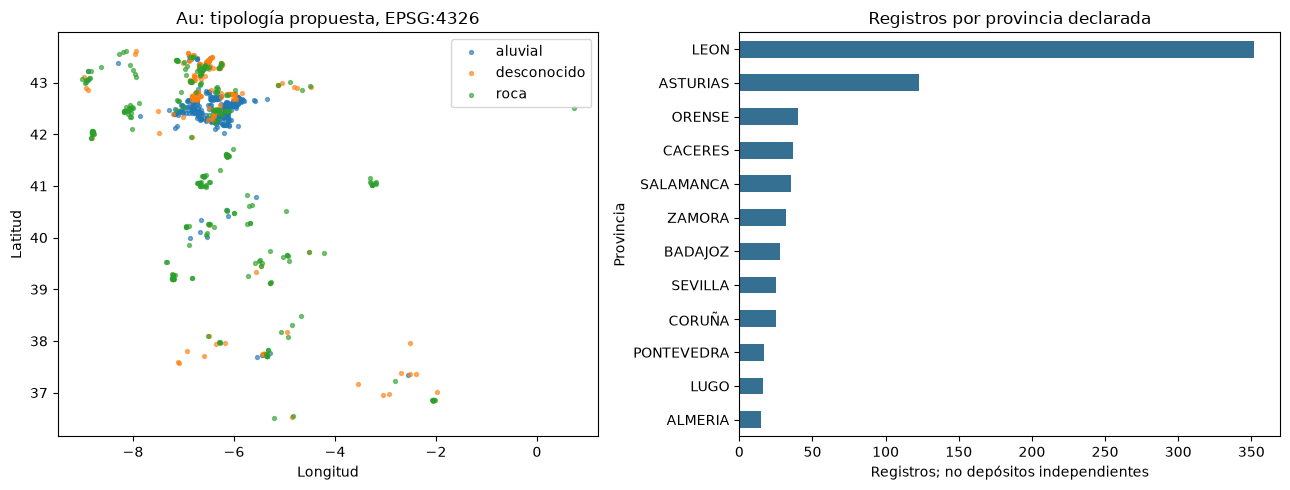

,registros; dominio declarado
Zona_Geode,
Cuenca del Duero - Almazán,35
Cuenca del Guadalquivir y cuencas béticas postorogénicas,21
Pirineos,1
Zona Asturoccidental-Leonesa,68
Zona Cantábrica,2
"Zona Centroibérica, dom. Esquisto-grauváquico",79
"Zona Centroibérica, dom. del Ollo de Sapo",7
Zona Sudportuguesa,4
Zona de Galicia Tras-os-Montes,61


In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13,5))
plot_data = etiquetas.loc[~etiquetas.geo_cuarentena]
for tipo, group in plot_data.groupby("tipo_au_propuesto"):
    axes[0].scatter(group.lon, group.lat, s=8, alpha=.6, label=tipo)
axes[0].set(xlabel="Longitud", ylabel="Latitud", title="Au: tipología propuesta, EPSG:4326")
axes[0].legend()
top = etiquetas.Provincia.fillna("Sin provincia").value_counts().head(12)
top.sort_values().plot.barh(ax=axes[1], color="#356f91")
axes[1].set(title="Registros por provincia declarada", xlabel="Registros; no depósitos independientes")
plt.tight_layout()
plt.show()
display(etiquetas.groupby("Zona_Geode",dropna=False).size().to_frame("registros; dominio declarado"))

## 10. Exportación y control de integridad

Se guardan CSV, GeoPackage y configuración en una carpeta nueva. Si no hay positivos
revisados, no se crea un GPKG revisado vacío que pueda confundirse con un resultado
terminado. La plantilla se genera sin decisiones inventadas y nunca se sobreescribe
el fichero de revisión que hayas aportado.

La ejecución automática puede finalizar correctamente mientras la fase B científica
sigue abierta: máscara, revisión de etiquetas, depósitos y distritos requieren trabajo
posterior. `control_cierre.json` distingue ambos estados.

In [20]:
RUN_DIR, control = export_phase_b(ROOT, CONFIG, A_RUN, MANIFEST_A, qc, etiquetas,
    conciliacion, duplicados_fuentes, decisiones, pares, sensibilidad, cobertura, extra_inputs)
au_solo_copias.to_csv(RUN_DIR / "au_ausentes_de_base_canonica.csv", index=False, encoding="utf-8-sig")
representantes_posicion.drop(columns="geometry").to_csv(RUN_DIR / "representantes_posicion_no_depositos.csv", index=False, encoding="utf-8-sig")
fig.savefig(RUN_DIR / "representatividad_au.png", dpi=140, bbox_inches="tight")
changes = verify_unchanged(ROOT, MANIFEST_A["sources"], rehash=True)
extra_changes = [r["path"] for r in extra_inputs if sha256_file(local_path(ROOT,r["path"])) != r["sha256"]]
control["fuentes_modificadas"] = changes
control["entradas_adicionales_modificadas"] = extra_changes
control["estado_ejecucion"] = "completada" if not changes and not extra_changes else "error_integridad"
write_json(RUN_DIR / "control_cierre.json", control)
assert not changes and not extra_changes, "Fuentes modificadas durante la ejecución: revisar trazabilidad."
print("Resultados:", RUN_DIR)
display(pd.Series(control, dtype=object).to_frame("resultado"))

Resultados: C:\Users\Lenovo\Desktop\PROYECTO IA\GeoAI\GeoAI\reports\fase_b\20260923T190207_727009Z


,resultado
estado_ejecucion,completada
fase_b_cientifica_cerrada,False
registros_base,11732
registros_au_observados,790
registros_candidatos_incluyendo_confirmaciones,790
posiciones_au_localizables,787
cuarentena_geometria_base,3
au_en_cuarentena,0
positivos_revisados,0
depositos_con_id_revisado,0


## 11. Cómo continuar la revisión

1. Revisar `reconciliacion_indicios.csv`, `au_ausentes_de_base_canonica.csv` y cuarentenas.
2. Copiar `plantilla_revision.csv` a una carpeta local de revisión y rellenar solo
   decisiones respaldadas por evidencia. No modificar IDs; conservar columnas.
3. Para un mismo depósito confirmado, asignar el mismo `deposit_id` a sus registros.
   `district_id` debe proceder de una delimitación revisada, no del algoritmo de proximidad.
4. Configurar la ruta en `config/labels.yaml` y volver a ejecutar el cuaderno.
5. Recuperar máscara/límites locales y completar geología antes de fijar la validación.

No se puede certificar desde BDMIN y proximidad por sí solos cuántos depósitos
independientes existen. El cuaderno deja esa incertidumbre visible y preserva todas
las relaciones para el diseño espacial posterior.

Referencia técnica: las distancias se calculan con
[PyProj Geod](https://pyproj4.github.io/pyproj/stable/api/geod.html);
el contraste opcional con polígonos usa
[GeoPandas sjoin](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html).